# Tahap 2 — Analisis Spasial Klaster Ekonomi Kreatif Jakarta
### JEF 2026 · Topik 4: Penguatan Infrastruktur Pendukung Ekonomi Kreatif

**Input** (dari Tahap 1): `poi_creative.gpkg`, `jakarta_studyarea.gpkg`, `worldpop_jakarta.tif`

**Hasil Tahap 1 yang dipakai:** 2.924 POI bersih, 12/12 subsektor, luas 648,9 km² (rasio 0,98 terhadap rujukan 664,01 km²), populasi 11,19 juta jiwa.

---
### ⚠️ Satu perbaikan wajib sebelum analisis
Tahap 1 menghasilkan **200 "kecamatan"**, padahal DKI Jakarta resmi memiliki **44 kecamatan (42 di daratan)** dan 267 kelurahan. Penyebabnya: penandaan `admin_level=6` di OSM Indonesia tidak konsisten — sebagian kelurahan ikut tertandai level 6, sehingga poligonnya **tumpang tindih**.

Ini **fatal** untuk statistik spasial: unit yang tumpang tindih membuat matriks bobot ketetanggaan tidak sah dan menghitung ganda POI yang sama. SEL 2 memperbaikinya dengan algoritma partisi greedy (poligon terbesar dipertahankan, yang bersarang di dalamnya dibuang) — sudah diuji memulihkan unit induk secara tepat tanpa mengubah cakupan wilayah.

**Catatan metodologis:** analisis utama memakai **grid heksagonal H3**, bukan batas administratif — ini menghindari *Modifiable Areal Unit Problem* (MAUP) dan bias bentuk/ukuran kecamatan yang sangat timpang. Kecamatan hanya dipakai untuk **agregasi rekomendasi kebijakan**, karena itulah unit yang dipakai pemerintah.

| Resolusi H3 | Luas per sel | Perkiraan jumlah sel | Dipakai untuk |
|---|---|---|---|
| Res 8 | ±0,745 km² | ±870 | Analisis utama (seluruh POI) |
| Res 7 | ±5,2 km² | ±125 | Uji ketahanan & skenario tanpa kuliner |


## SEL 1 — SETUP

In [1]:
# ============ SEL 1: SETUP ============
import os, sys, glob, sqlite3, json, warnings, time
from pathlib import Path
from datetime import datetime, timezone
warnings.filterwarnings("ignore")

# --- PROJ GUARD (sama seperti Tahap 1) ---
_cands = [os.path.join(sys.prefix, "share", "proj"),
          os.path.join(sys.prefix, "Library", "share", "proj")]
try:
    import pyproj
    _cands.append(os.path.join(os.path.dirname(pyproj.__file__), "proj_dir", "share", "proj"))
except Exception:
    pass
for c in _cands:
    if os.path.exists(os.path.join(c, "proj.db")):
        os.environ["PROJ_LIB"] = os.environ["PROJ_DATA"] = c
        try:
            import pyproj; pyproj.datadir.set_data_dir(c)
        except Exception: pass
        print("PROJ:", c)
        break
os.environ["SHAPE_RESTORE_SHX"] = "YES"

import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import rasterio, h3
from shapely.geometry import Polygon, mapping
from shapely.ops import unary_union
from scipy.stats import entropy as shannon_entropy
from sklearn.cluster import DBSCAN
from libpysal.weights import Queen, KNN
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local

print(f"geopandas {gpd.__version__} | h3 {h3.__version__}")

# --- PARAMETER ---
CRS_GEO, CRS_METRIC = 4326, 32748
H3_MAIN, H3_COARSE  = 8, 7          # resolusi utama & kasar
KEC_TARGET          = 42            # kecamatan daratan DKI (44 total - 2 Kep. Seribu)
JAKARTA_LAND_KM2    = 662.0
DBSCAN_EPS_M        = 400           # radius ketetanggaan klaster (meter)
DBSCAN_MIN_SAMPLES  = 10
SIG                 = 0.05

BASE = Path.cwd()
PROC = BASE / "data" / "processed"
FIG  = BASE / "outputs" / "figures"
TAB  = BASE / "outputs" / "tables"
for p in (FIG, TAB): p.mkdir(parents=True, exist_ok=True)

CULINARY = {"kuliner_kafe", "kuliner_restoran"}
SUBSEKTOR_LABEL = {
    "seni_pertunjukan":"Seni Pertunjukan","seni_rupa_galeri":"Seni Rupa & Galeri","musik":"Musik",
    "film_sinema":"Film & Sinema","kriya":"Kriya","fesyen":"Fesyen",
    "penerbitan_literasi":"Penerbitan & Literasi","desain_layanan_kreatif":"Desain & Layanan Kreatif",
    "coworking_hub":"Coworking / Creative Hub","fotografi":"Fotografi",
    "kuliner_kafe":"Kuliner - Kafe","kuliner_restoran":"Kuliner - Restoran"}

mpl.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "font.size": 9,
                     "axes.titlesize": 11, "axes.titleweight": "bold"})

RESULTS = {"run_utc": datetime.now(timezone.utc).isoformat(), "params": {
    "h3_main": H3_MAIN, "h3_coarse": H3_COARSE, "dbscan_eps_m": DBSCAN_EPS_M,
    "dbscan_min_samples": DBSCAN_MIN_SAMPLES, "alpha": SIG}}

print("SETUP SELESAI |", PROC)


PROJ: ~/miniforge3/envs/r2c-dl/share/proj
geopandas 1.1.3 | h3 4.5.0
SETUP SELESAI | <folder-proyek>/data/processed


## SEL 2 — Muat data & perbaiki unit kecamatan

In [2]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

poi = gpd.read_file(PROC / "poi_creative.gpkg", layer="poi").to_crs(CRS_GEO)
kec_raw = gpd.read_file(PROC / "jakarta_studyarea.gpkg", layer="kecamatan").to_crs(CRS_GEO)
study_area = gpd.read_file(PROC / "jakarta_studyarea.gpkg", layer="study_area").geometry.iloc[0]
print(f"Dimuat: {len(poi)} POI | {len(kec_raw)} unit batas mentah")

def dedup_partition(gdf, overlap_thresh=0.30):
    # Greedy: pertahankan poligon TERBESAR; buang yang >30% luasnya sudah tertutup unit terpilih
    g = gdf.to_crs(CRS_METRIC).copy()
    g["_a"] = g.geometry.area
    g = g.sort_values("_a", ascending=False)
    kept, acc = [], None
    for idx, row in g.iterrows():
        gm = row.geometry
        if acc is not None and gm.intersection(acc).area / max(gm.area, 1e-12) > overlap_thresh:
            continue
        kept.append(idx)
        acc = gm if acc is None else unary_union([acc, gm])
    return gdf.loc[kept].copy()

area_before = kec_raw.to_crs(CRS_METRIC).geometry.union_all().area / 1e6
kec = dedup_partition(kec_raw).reset_index(drop=True)
area_after = kec.to_crs(CRS_METRIC).geometry.union_all().area / 1e6

print(f"\nPartisi: {len(kec_raw)} -> {len(kec)} unit")
print(f"Cakupan wilayah: {area_before:,.1f} -> {area_after:,.1f} km2 (harus nyaris sama)")
print(f"Rujukan resmi: {KEC_TARGET} kecamatan daratan, {JAKARTA_LAND_KM2:.0f} km2")

if abs(len(kec) - KEC_TARGET) > 6:
    print(f"PERINGATAN: jumlah unit ({len(kec)}) masih jauh dari {KEC_TARGET}.")
    print("  Periksa daftar nama di bawah; sesuaikan overlap_thresh bila perlu.")
else:
    print("Jumlah unit: WAJAR")

kec["luas_km2"] = kec.to_crs(CRS_METRIC).area / 1e6
kec = kec.sort_values("kecamatan").reset_index(drop=True)
print(f"\nDaftar {len(kec)} unit (periksa terhadap daftar resmi 42 kecamatan):")
for i, r in kec.iterrows():
    print(f"  {i+1:2d}. {str(r['kecamatan'])[:28]:30s} {r['luas_km2']:7.2f} km2   [{str(r['kabkota'])[:22]}]")

kec.to_file(PROC / "kecamatan_bersih.gpkg", driver="GPKG")
RESULTS["kecamatan"] = {"n_raw": int(len(kec_raw)), "n_clean": int(len(kec)),
                        "area_km2": round(float(area_after), 1)}


Dimuat: 2924 POI | 200 unit batas mentah

Partisi: 200 -> 44 unit
Cakupan wilayah: 648.9 -> 648.9 km2 (harus nyaris sama)
Rujukan resmi: 42 kecamatan daratan, 662 km2
Jumlah unit: WAJAR

Daftar 44 unit (periksa terhadap daftar resmi 42 kecamatan):
   1. Cakung                           40.40 km2   [Jakarta Timur]
   2. Cempaka Putih                     4.71 km2   [Jakarta Pusat]
   3. Cengkareng                       25.69 km2   [Jakarta Barat]
   4. Cilandak                         17.55 km2   [Jakarta Selatan]
   5. Cilincing                        42.07 km2   [Jakarta Utara]
   6. Cipayung                         28.54 km2   [Jakarta Timur]
   7. Ciracas                          16.54 km2   [Jakarta Timur]
   8. Duren Sawit                      22.02 km2   [Jakarta Timur]
   9. Gambir                            7.49 km2   [Jakarta Pusat]
  10. Grogol Petamburan                10.73 km2   [Jakarta Barat]
  11. Jagakarsa                        25.14 km2   [Jakarta Selatan]
  12. Jatin

## SEL 3 — Grid H3 & agregasi indikator
Membangun grid heksagonal, lalu menghitung per sel: jumlah POI (total, per subsektor, non-kuliner), populasi (WorldPop), dan akses transit.

In [3]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

def build_h3_grid(poly, res):
    cells = h3.geo_to_cells(mapping(poly), res)
    rows = []
    for c in cells:
        b = h3.cell_to_boundary(c)                       # (lat, lng)
        rows.append({"h3": c, "geometry": Polygon([(lng, lat) for lat, lng in b])})
    g = gpd.GeoDataFrame(rows, crs=CRS_GEO)
    g = g[g.geometry.intersects(poly)].reset_index(drop=True)
    g["luas_km2"] = g.to_crs(CRS_METRIC).area / 1e6
    return g

def assign_h3(points, res):
    return [h3.latlng_to_cell(y, x, res) for x, y in zip(points.geometry.x, points.geometry.y)]

def pop_per_polygon(gdf, raster_path):
    # Rasterisasi indeks poligon lalu jumlahkan populasi per indeks (cepat & tepat)
    from rasterio.features import rasterize
    with rasterio.open(raster_path) as src:
        arr = src.read(1).astype("float64")
        if src.nodata is not None: arr[arr == src.nodata] = np.nan
        arr[arr < 0] = np.nan
        shapes = ((geom, i + 1) for i, geom in enumerate(gdf.to_crs(src.crs).geometry))
        idx = rasterize(shapes, out_shape=arr.shape, transform=src.transform,
                        fill=0, dtype="int32")
    flat_i, flat_v = idx.ravel(), np.nan_to_num(arr.ravel())
    sums = np.bincount(flat_i, weights=flat_v, minlength=len(gdf) + 1)
    return sums[1:]

grids = {}
for res in (H3_MAIN, H3_COARSE):
    g = build_h3_grid(study_area, res)
    poi_r = poi.copy()
    poi_r["h3"] = assign_h3(poi_r, res)
    tot = poi_r.groupby("h3").size().rename("n_poi")
    ncul = poi_r[~poi_r["subsector"].isin(CULINARY)].groupby("h3").size().rename("n_poi_noncul")
    wide = poi_r.pivot_table(index="h3", columns="subsector", aggfunc="size", fill_value=0)
    g = g.set_index("h3").join([tot, ncul, wide]).fillna(0).reset_index()
    g["populasi"] = pop_per_polygon(g, PROC / "worldpop_jakarta.tif")
    g["dens_poi"]  = g["n_poi"] / g["luas_km2"]
    g["dens_ncul"] = g["n_poi_noncul"] / g["luas_km2"]
    g["dens_pop"]  = g["populasi"] / g["luas_km2"]
    grids[res] = g
    print(f"Res {res}: {len(g):4d} sel | luas rata2 {g['luas_km2'].mean():.3f} km2 | "
          f"POI/sel {g['n_poi'].mean():.2f} | sel kosong {(g['n_poi']==0).mean()*100:.1f}%")

hexes = grids[H3_MAIN]
print(f"\nValidasi silang: total populasi grid = {hexes['populasi'].sum():,.0f} "
      f"(Tahap 1: ~11,19 juta)")
print(f"                 total POI grid      = {int(hexes['n_poi'].sum())} (Tahap 1: {len(poi)})")

# --- Akses transit ---
try:
    st = gpd.read_file(PROC / "transit.gpkg", layer="stations").to_crs(CRS_METRIC)
    bs = gpd.read_file(PROC / "transit.gpkg", layer="bus_stops").to_crs(CRS_METRIC)
    transit = gpd.GeoDataFrame(geometry=pd.concat([st.geometry, bs.geometry], ignore_index=True),
                               crs=CRS_METRIC)
    for res, g in grids.items():
        cen = g.to_crs(CRS_METRIC).geometry.centroid
        d = cen.apply(lambda p: transit.distance(p).min())
        g["jarak_transit_m"] = d.values
    print(f"Transit: {len(transit)} titik | jarak median dari pusat sel: "
          f"{hexes['jarak_transit_m'].median():.0f} m")
except Exception as e:
    print("Transit tidak tersedia:", type(e).__name__, e)
    for g in grids.values(): g["jarak_transit_m"] = np.nan


Res 8:  870 sel | luas rata2 0.745 km2 | POI/sel 3.33 | sel kosong 47.1%
Res 7:  126 sel | luas rata2 5.214 km2 | POI/sel 22.83 | sel kosong 13.5%

Validasi silang: total populasi grid = 10,987,928 (Tahap 1: ~11,19 juta)
                 total POI grid      = 2900 (Tahap 1: 2924)
Transit: 4574 titik | jarak median dari pusat sel: 295 m


## SEL 4 — Diversitas subsektor (entropi Shannon)
Membedakan kawasan "monokultur" (mis. hanya kuliner) dari ekosistem kreatif yang benar-benar beragam. Entropi dinormalisasi 0–1.

In [4]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

SUBS = [c for c in hexes.columns if c in SUBSEKTOR_LABEL]

def shannon_norm(row, cols):
    v = np.array([row[c] for c in cols], dtype=float)
    if v.sum() == 0: return np.nan
    p = v[v > 0] / v.sum()
    k = (v > 0).sum()
    if k <= 1: return 0.0
    return float(shannon_entropy(p, base=2) / np.log2(len(cols)))

for res, g in grids.items():
    cols = [c for c in g.columns if c in SUBSEKTOR_LABEL]
    g["entropi"] = g.apply(lambda r: shannon_norm(r, cols), axis=1)
    g["n_subsektor"] = (g[cols] > 0).sum(axis=1)

hexes = grids[H3_MAIN]
terisi = hexes[hexes["n_poi"] > 0]
print(f"Sel terisi POI: {len(terisi)} dari {len(hexes)} ({len(terisi)/len(hexes)*100:.1f}%)")
print(f"Entropi rata-rata (sel terisi): {terisi['entropi'].mean():.3f}")
print(f"Jumlah subsektor per sel (median): {terisi['n_subsektor'].median():.0f}")
print("\nSel paling beragam (entropi tertinggi, minimal 20 POI):")
top = terisi[terisi["n_poi"] >= 20].nlargest(5, "entropi")
for _, r in top.iterrows():
    print(f"  {r['h3']}  entropi={r['entropi']:.3f}  POI={int(r['n_poi'])}  subsektor={int(r['n_subsektor'])}")


Sel terisi POI: 460 dari 870 (52.9%)
Entropi rata-rata (sel terisi): 0.186
Jumlah subsektor per sel (median): 2

Sel paling beragam (entropi tertinggi, minimal 20 POI):
  888c106a0dfffff  entropi=0.615  POI=25  subsektor=6
  888c1078d7fffff  entropi=0.603  POI=31  subsektor=8
  888c107991fffff  entropi=0.540  POI=36  subsektor=7
  888c107995fffff  entropi=0.530  POI=25  subsektor=6
  888c106329fffff  entropi=0.525  POI=46  subsektor=5


## SEL 5 — Autokorelasi spasial: Moran's I, LISA, Getis-Ord Gi*
Menguji apakah ekonomi kreatif Jakarta benar-benar **terklaster secara statistik**, bukan sekadar terlihat menggerombol di peta.

In [5]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

def spatial_stats(g, value_col, label):
    gg = g.reset_index(drop=True).copy()
    w = Queen.from_dataframe(gg, use_index=True)
    if w.islands:
        w = KNN.from_dataframe(gg, k=6)      # cadangan bila ada sel terisolasi
        wtype = "KNN(k=6)"
    else:
        wtype = "Queen"
    w.transform = "r"
    y = gg[value_col].values.astype(float)
    mi = Moran(y, w)
    lisa = Moran_Local(y, w, seed=42)
    gi = G_Local(y, w, star=True, seed=42)
    gg["lisa_q"], gg["lisa_p"] = lisa.q, lisa.p_sim
    gg["gi_z"], gg["gi_p"] = gi.Zs, gi.p_sim
    lab = {1: "HH (klaster kreatif)", 2: "LH (outlier rendah)",
           3: "LL (gurun kreatif)", 4: "HL (outlier tinggi)"}
    gg["lisa_label"] = np.where(gg["lisa_p"] < SIG, gg["lisa_q"].map(lab), "Tidak signifikan")
    print(f"\n--- {label} (bobot {wtype}, n={len(gg)}) ---")
    print(f"Moran's I = {mi.I:.4f} | E[I] = {mi.EI:.4f} | z = {mi.z_sim:.2f} | p = {mi.p_sim:.4f}")
    interp = ("terklaster (positif, signifikan)" if mi.I > 0 and mi.p_sim < SIG
              else "menyebar/acak" if mi.p_sim >= SIG else "tersebar (negatif)")
    print(f"Kesimpulan: pola spasial {interp}")
    print(gg["lisa_label"].value_counts().to_string())
    print(f"Hot spot Gi* (z>1,96): {int((gg['gi_z']>1.96).sum())} | "
          f"Cold spot (z<-1,96): {int((gg['gi_z']<-1.96).sum())}")
    return gg, {"moran_I": float(mi.I), "EI": float(mi.EI), "z": float(mi.z_sim),
                "p": float(mi.p_sim), "weights": wtype, "n": int(len(gg)),
                "HH": int((gg["lisa_label"].str.startswith("HH")).sum()),
                "LL": int((gg["lisa_label"].str.startswith("LL")).sum()),
                "hot": int((gg["gi_z"] > 1.96).sum()), "cold": int((gg["gi_z"] < -1.96).sum())}

hexes, stat_all = spatial_stats(grids[H3_MAIN], "dens_poi", f"SELURUH POI (H3 res {H3_MAIN})")
RESULTS["moran_all_res8"] = stat_all
grids[H3_MAIN] = hexes



--- SELURUH POI (H3 res 8) (bobot KNN(k=6), n=870) ---
Moran's I = 0.3688 | E[I] = -0.0012 | z = 18.84 | p = 0.0010
Kesimpulan: pola spasial terklaster (positif, signifikan)
lisa_label
Tidak signifikan        607
LL (gurun kreatif)      186
HH (klaster kreatif)     61
LH (outlier rendah)      14
HL (outlier tinggi)       2
Hot spot Gi* (z>1,96): 28 | Cold spot (z<-1,96): 0


## SEL 6 — Uji sensitivitas kuliner & ketahanan resolusi
Kuliner menyumbang **87,1%** dari seluruh POI, jadi wajib dibuktikan bahwa temuan klaster bukan sekadar pola sebaran restoran.

In [6]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

scen = []
h8_ncul, s1 = spatial_stats(grids[H3_MAIN], "dens_ncul", f"TANPA KULINER (H3 res {H3_MAIN})")
scen.append(("Tanpa kuliner, res 8", s1))
h7_all, s2 = spatial_stats(grids[H3_COARSE], "dens_poi", f"SELURUH POI (H3 res {H3_COARSE})")
scen.append(("Seluruh POI, res 7", s2))
h7_ncul, s3 = spatial_stats(grids[H3_COARSE], "dens_ncul", f"TANPA KULINER (H3 res {H3_COARSE})")
scen.append(("Tanpa kuliner, res 7", s3))

rows = [{"Skenario": "Seluruh POI, res 8", **{k: stat_all[k] for k in ("moran_I","z","p","HH","LL","n")}}]
for nm, s in scen:
    rows.append({"Skenario": nm, **{k: s[k] for k in ("moran_I","z","p","HH","LL","n")}})
sens = pd.DataFrame(rows)
sens.columns = ["Skenario","Moran's I","z","p","Sel HH","Sel LL","n sel"]
sens.to_csv(TAB / "tabel_sensitivitas_moran.csv", index=False)
print("\n=== RINGKASAN UJI SENSITIVITAS ===")
print(sens.round(4).to_string(index=False))
konsisten = all(r["Moran's I"] > 0 and r["p"] < SIG for _, r in sens.iterrows())
print("\nKESIMPULAN:", "Klaster TETAP signifikan di semua skenario — temuan kokoh."
      if konsisten else "Ada skenario yang tidak signifikan — laporkan apa adanya di paper.")
RESULTS["sensitivitas"] = sens.to_dict("records")
grids[H3_COARSE] = h7_all



--- TANPA KULINER (H3 res 8) (bobot KNN(k=6), n=870) ---
Moran's I = 0.2606 | E[I] = -0.0012 | z = 13.86 | p = 0.0010
Kesimpulan: pola spasial terklaster (positif, signifikan)
lisa_label
Tidak signifikan        446
LL (gurun kreatif)      335
HH (klaster kreatif)     50
LH (outlier rendah)      26
HL (outlier tinggi)      13
Hot spot Gi* (z>1,96): 15 | Cold spot (z<-1,96): 0

--- SELURUH POI (H3 res 7) (bobot KNN(k=6), n=126) ---
Moran's I = 0.4247 | E[I] = -0.0080 | z = 9.29 | p = 0.0010
Kesimpulan: pola spasial terklaster (positif, signifikan)
lisa_label
Tidak signifikan        82
LL (gurun kreatif)      24
HH (klaster kreatif)    18
LH (outlier rendah)      1
HL (outlier tinggi)      1
Hot spot Gi* (z>1,96): 3 | Cold spot (z<-1,96): 0

--- TANPA KULINER (H3 res 7) (bobot KNN(k=6), n=126) ---
Moran's I = 0.4343 | E[I] = -0.0080 | z = 9.36 | p = 0.0010
Kesimpulan: pola spasial terklaster (positif, signifikan)
lisa_label
Tidak signifikan        86
LL (gurun kreatif)      18
HH (klaste

## SEL 7 — DBSCAN: deliniasi klaster organik
Melihat batas klaster yang terbentuk alami dari sebaran titik, tanpa dipaksa mengikuti garis administratif.

In [7]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

pts = poi.to_crs(CRS_METRIC)
XY = np.column_stack([pts.geometry.x, pts.geometry.y])
db = DBSCAN(eps=DBSCAN_EPS_M, min_samples=DBSCAN_MIN_SAMPLES).fit(XY)
poi["cluster"] = db.labels_
n_cl = len(set(db.labels_) - {-1})
noise = int((db.labels_ == -1).sum())
print(f"DBSCAN (eps={DBSCAN_EPS_M} m, min_samples={DBSCAN_MIN_SAMPLES}):")
print(f"  Klaster terdeteksi : {n_cl}")
print(f"  Titik terklaster   : {len(poi)-noise} ({(len(poi)-noise)/len(poi)*100:.1f}%)")
print(f"  Titik sebar (noise): {noise}")

cl_rows = []
for cid, grp in poi[poi["cluster"] >= 0].groupby("cluster"):
    gm = grp.to_crs(CRS_METRIC)
    hull = gm.geometry.union_all().convex_hull
    cnt = grp["subsector"].value_counts()
    p = cnt.values / cnt.values.sum()
    ent = float(shannon_entropy(p, base=2) / np.log2(len(SUBSEKTOR_LABEL))) if len(cnt) > 1 else 0.0
    sj = gpd.sjoin(grp[["geometry"]].to_crs(CRS_GEO), kec[["kecamatan","geometry"]],
                   how="left", predicate="within")
    cl_rows.append({
        "klaster": int(cid), "n_poi": len(grp),
        "luas_km2": round(hull.area / 1e6, 3),
        "kepadatan_poi_km2": round(len(grp) / max(hull.area / 1e6, 1e-6), 1),
        "n_subsektor": int(grp["subsector"].nunique()),
        "entropi": round(ent, 3),
        "subsektor_dominan": SUBSEKTOR_LABEL.get(cnt.index[0], cnt.index[0]),
        "pangsa_dominan_%": round(cnt.iloc[0] / len(grp) * 100, 1),
        "n_nonkuliner": int((~grp["subsector"].isin(CULINARY)).sum()),
        "kecamatan_utama": (sj["kecamatan"].mode().iloc[0]
                            if not sj["kecamatan"].dropna().empty else "-")})
clusters = pd.DataFrame(cl_rows).sort_values("n_poi", ascending=False).reset_index(drop=True)
clusters.to_csv(TAB / "tabel_klaster_dbscan.csv", index=False)
print("\n10 klaster terbesar:")
print(clusters.head(10).to_string(index=False))
RESULTS["dbscan"] = {"n_clusters": int(n_cl), "noise": noise, "eps_m": DBSCAN_EPS_M}


DBSCAN (eps=400 m, min_samples=10):
  Klaster terdeteksi : 34
  Titik terklaster   : 1966 (67.2%)
  Titik sebar (noise): 958

10 klaster terbesar:
 klaster  n_poi  luas_km2  kepadatan_poi_km2  n_subsektor  entropi  subsektor_dominan  pangsa_dominan_%  n_nonkuliner   kecamatan_utama
       2    409    11.796               34.7           11    0.457 Kuliner - Restoran              59.7            47         Setiabudi
      10    279     4.427               63.0            8    0.393 Kuliner - Restoran              69.9            30 Grogol Petamburan
       0    155     4.563               34.0            9    0.411 Kuliner - Restoran              68.4            17    Kebayoran Baru
      17    148     3.954               37.4            6    0.398 Kuliner - Restoran              59.5            14             Tebet
      21    134     0.863              155.4            4    0.270 Kuliner - Restoran              75.4             4          Palmerah
       4    129     3.813            

## SEL 8 — Indeks Kecukupan Infrastruktur Kreatif & peta gap prioritas
Menggabungkan pasokan (densitas + diversitas + akses transit) lalu membandingkannya dengan permintaan (populasi) untuk menemukan **"gurun kreatif" berprioritas tinggi**: penduduk padat, infrastruktur minim, tapi dekat transit sehingga intervensi layak dan murah.

In [8]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

def minmax(s):
    s = pd.to_numeric(s, errors="coerce")
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng and rng > 0 else pd.Series(0.0, index=s.index)

h = grids[H3_MAIN].copy()
h["z_dens"]    = minmax(np.log1p(h["dens_poi"]))
h["z_div"]     = minmax(h["entropi"].fillna(0))
h["z_transit"] = 1 - minmax(np.log1p(h["jarak_transit_m"].fillna(h["jarak_transit_m"].max())))
h["IKIK"]      = 0.5 * h["z_dens"] + 0.3 * h["z_div"] + 0.2 * h["z_transit"]   # pasokan
h["z_pop"]     = minmax(np.log1p(h["dens_pop"]))                                # permintaan

# GAP memakai PERINGKAT PERSENTIL, bukan min-max: pasokan & permintaan jadi setara
# skalanya, gap simetris di sekitar 0, dan tafsirnya jelas (selisih peringkat).
h["pct_pop"]  = h["dens_pop"].rank(pct=True)
h["pct_IKIK"] = h["IKIK"].rank(pct=True)
h["gap"]      = h["pct_pop"] - h["pct_IKIK"]
h["prioritas"] = h["gap"] * h["z_transit"]      # gap besar + transit dekat = paling layak digarap

kurang = int((h["gap"] > 0.2).sum())
print("Indeks Kecukupan Infrastruktur Kreatif (IKIK) = 0,5*densitas + 0,3*diversitas + 0,2*akses transit")
print(f"  IKIK  : rata2 {h['IKIK'].mean():.3f} | median {h['IKIK'].median():.3f}")
print(f"  Gap   : median {h['gap'].median():+.3f} (simetris di sekitar 0 sesuai konstruksi)")
print(f"  Sel kurang terlayani nyata (gap > 0,2): {kurang} dari {len(h)} ({kurang/len(h)*100:.1f}%)")
print(f"  Sel terlayani berlebih (gap < -0,2)   : {int((h['gap']<-0.2).sum())}")

# Agregasi ke kecamatan untuk rekomendasi kebijakan
hm = h.to_crs(CRS_METRIC).copy()
hm["geometry"] = hm.geometry.centroid
hk = gpd.sjoin(hm.to_crs(CRS_GEO), kec[["kecamatan","kabkota","geometry"]],
               how="left", predicate="within")
agg = (hk.groupby("kecamatan")
         .agg(n_poi=("n_poi","sum"), n_nonkuliner=("n_poi_noncul","sum"),
              populasi=("populasi","sum"), luas_km2=("luas_km2","sum"),
              IKIK=("IKIK","mean"), entropi=("entropi","mean"),
              gap=("gap","mean"), prioritas=("prioritas","mean"),
              jarak_transit_m=("jarak_transit_m","median"),
              kabkota=("kabkota","first")).reset_index())
agg["poi_per_km2"]      = agg["n_poi"] / agg["luas_km2"]
agg["poi_per_10k_jiwa"] = agg["n_poi"] / (agg["populasi"] / 1e4).replace(0, np.nan)
agg = agg.sort_values("prioritas", ascending=False).reset_index(drop=True)
agg.round(3).to_csv(TAB / "tabel_prioritas_kecamatan.csv", index=False)

print("\n=== 10 KECAMATAN PRIORITAS INTERVENSI (gap tertinggi, akses transit baik) ===")
cols = ["kecamatan","kabkota","populasi","n_poi","n_nonkuliner","IKIK","gap","prioritas"]
print(agg[cols].head(10).round(3).to_string(index=False))
print("\n=== 10 KECAMATAN PALING TERLAYANI (klaster kreatif mapan) ===")
print(agg[cols].tail(10).iloc[::-1].round(3).to_string(index=False))

grids[H3_MAIN] = h
RESULTS["ikik"] = {"mean": float(h["IKIK"].mean()), "n_gap_positif": int((h["gap"]>0.2).sum())}


Indeks Kecukupan Infrastruktur Kreatif (IKIK) = 0,5*densitas + 0,3*diversitas + 0,2*akses transit
  IKIK  : rata2 0.249 | median 0.183
  Gap   : median +0.010 (simetris di sekitar 0 sesuai konstruksi)
  Sel kurang terlayani nyata (gap > 0,2): 224 dari 870 (25.7%)
  Sel terlayani berlebih (gap < -0,2)   : 216

=== 10 KECAMATAN PRIORITAS INTERVENSI (gap tertinggi, akses transit baik) ===
    kecamatan       kabkota   populasi  n_poi  n_nonkuliner  IKIK   gap  prioritas
   Johar Baru Jakarta Pusat  87410.928    7.0           0.0 0.234 0.333      0.192
     Matraman Jakarta Timur 146241.825   18.0           1.0 0.294 0.294      0.164
  Duren Sawit Jakarta Timur 470882.594   23.0           0.0 0.188 0.254      0.154
Cempaka Putih Jakarta Pusat 117506.003   14.0           4.0 0.318 0.216      0.135
    Kemayoran Jakarta Pusat 162780.903   15.0           4.0 0.311 0.232      0.132
  Pulo Gadung Jakarta Timur 331345.864   26.0           2.0 0.206 0.242      0.131
  Kebon Jeruk Jakarta Barat 40

## SEL 9 — Peta untuk paper & presentasi

  tersimpan: fig1_densitas.png


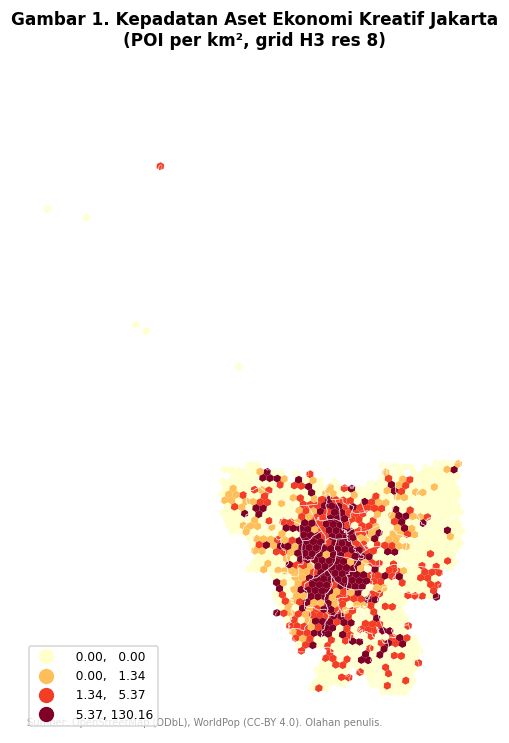

  tersimpan: fig2_lisa.png


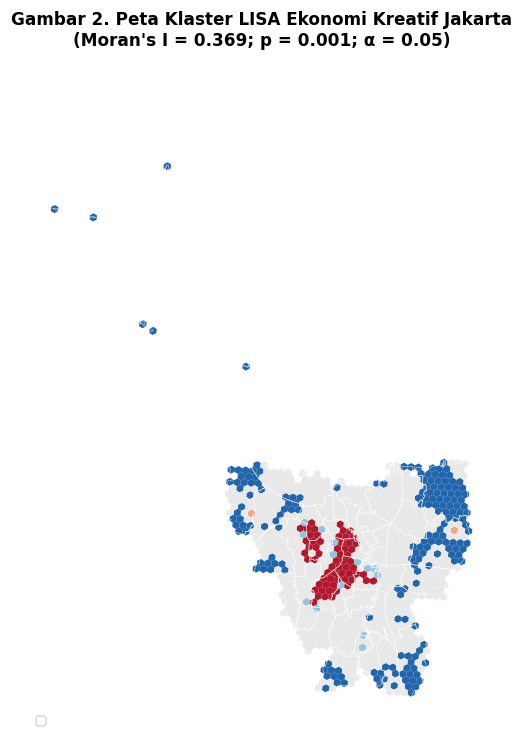

  tersimpan: fig3_getis.png


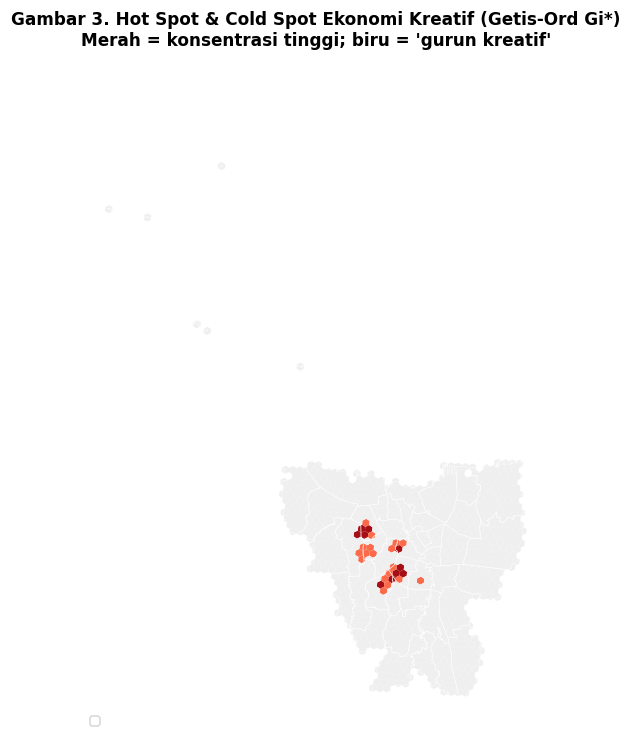

  tersimpan: fig4_entropi.png


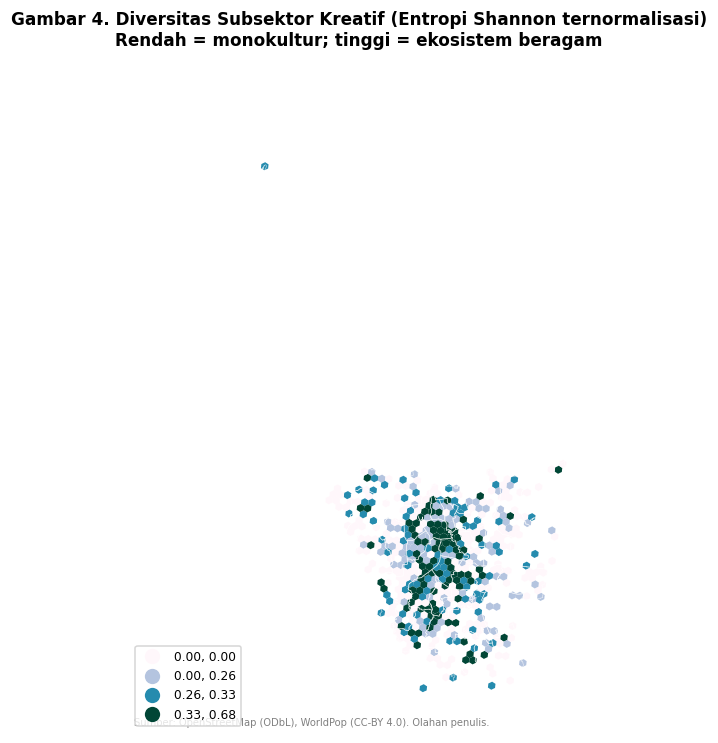

  tersimpan: fig5_prioritas.png


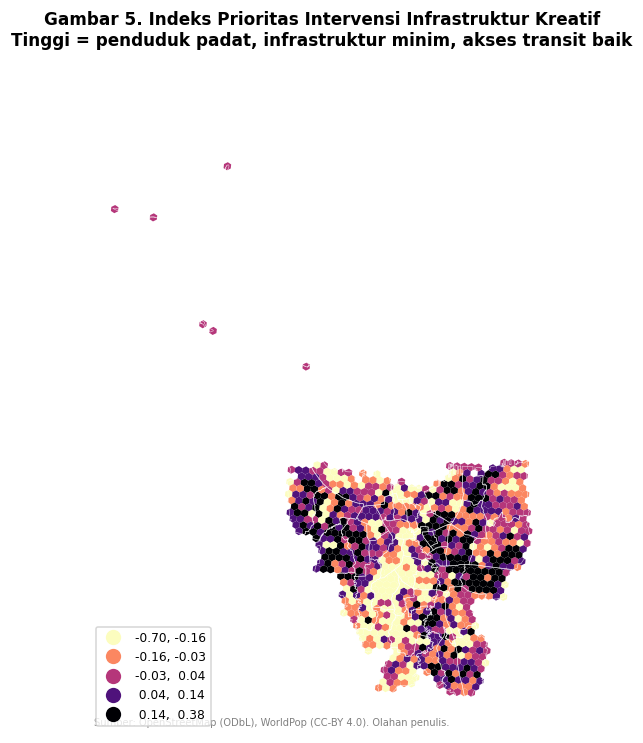

  tersimpan: fig6_dbscan.png


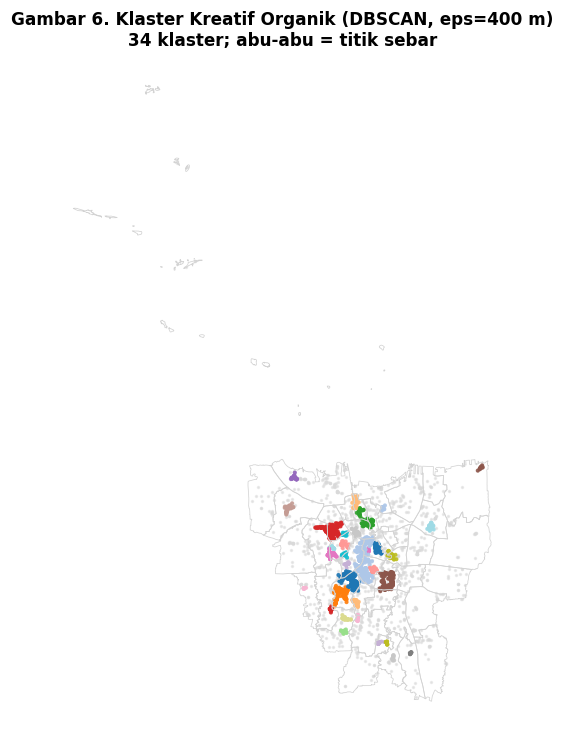

In [9]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

def peta(g, col, judul, cmap="viridis", scheme="quantiles", k=5, fname=None, label=None):
    fig, ax = plt.subplots(figsize=(9.5, 8))
    if scheme is None:
        # colorbar kontinu: HANYA menerima argumen Colorbar (shrink/label), bukan fontsize/loc
        g.plot(column=col, ax=ax, cmap=cmap, legend=True, linewidth=0,
               legend_kwds={"shrink": 0.55, "label": label or col})
    else:
        g.plot(column=col, ax=ax, cmap=cmap, scheme=scheme, k=k, legend=True, linewidth=0,
               legend_kwds={"fontsize": 8, "loc": "lower left"})
    kec.boundary.plot(ax=ax, color="white", linewidth=0.4, alpha=0.7)
    ax.set_title(judul, fontsize=11)
    ax.set_axis_off()
    ax.annotate("Sumber: OpenStreetMap (ODbL), WorldPop (CC-BY 4.0). Olahan penulis.",
                xy=(0.01, 0.01), xycoords="axes fraction", fontsize=6.5, color="grey")
    if fname:
        fig.savefig(FIG / fname, bbox_inches="tight")
        print("  tersimpan:", fname)
    plt.show()

h = grids[H3_MAIN]
peta(h, "dens_poi", f"Gambar 1. Kepadatan Aset Ekonomi Kreatif Jakarta\n(POI per km², grid H3 res {H3_MAIN})",
     "YlOrRd", fname="fig1_densitas.png")

warna = {"HH (klaster kreatif)": "#b2182b", "LL (gurun kreatif)": "#2166ac",
         "LH (outlier rendah)": "#92c5de", "HL (outlier tinggi)": "#f4a582",
         "Tidak signifikan": "#e8e8e8"}
fig, ax = plt.subplots(figsize=(9.5, 8))
for lab, sub in h.groupby("lisa_label"):
    sub.plot(ax=ax, color=warna.get(lab, "#cccccc"), linewidth=0, label=f"{lab} (n={len(sub)})")
kec.boundary.plot(ax=ax, color="white", linewidth=0.4, alpha=0.7)
ax.legend(fontsize=8, loc="lower left", frameon=True)
ax.set_title(f"Gambar 2. Peta Klaster LISA Ekonomi Kreatif Jakarta\n"
             f"(Moran's I = {stat_all['moran_I']:.3f}; p = {stat_all['p']:.3f}; α = {SIG})", fontsize=11)
ax.set_axis_off()
fig.savefig(FIG / "fig2_lisa.png", bbox_inches="tight"); print("  tersimpan: fig2_lisa.png")
plt.show()

# Gi* disajikan sebagai KELAS SIGNIFIKANSI (konvensi baku), bukan nilai z mentah
def kelas_gi(z):
    if z > 2.58:  return "Hot spot 99%"
    if z > 1.96:  return "Hot spot 95%"
    if z < -2.58: return "Cold spot 99%"
    if z < -1.96: return "Cold spot 95%"
    return "Tidak signifikan"
h["gi_kelas"] = h["gi_z"].apply(kelas_gi)
warna_gi = {"Hot spot 99%": "#a50f15", "Hot spot 95%": "#fb6a4a", "Tidak signifikan": "#efefef",
            "Cold spot 95%": "#6baed6", "Cold spot 99%": "#08519c"}
fig, ax = plt.subplots(figsize=(9.5, 8))
for lab in ["Hot spot 99%","Hot spot 95%","Tidak signifikan","Cold spot 95%","Cold spot 99%"]:
    sub = h[h["gi_kelas"] == lab]
    if len(sub):
        sub.plot(ax=ax, color=warna_gi[lab], linewidth=0, label=f"{lab} (n={len(sub)})")
kec.boundary.plot(ax=ax, color="white", linewidth=0.4, alpha=0.7)
ax.legend(fontsize=8, loc="lower left", frameon=True)
ax.set_title("Gambar 3. Hot Spot & Cold Spot Ekonomi Kreatif (Getis-Ord Gi*)\n"
             "Merah = konsentrasi tinggi; biru = 'gurun kreatif'", fontsize=11)
ax.set_axis_off()
fig.savefig(FIG / "fig3_getis.png", bbox_inches="tight"); print("  tersimpan: fig3_getis.png")
plt.show()
grids[H3_MAIN] = h
peta(h[h["n_poi"] > 0], "entropi",
     "Gambar 4. Diversitas Subsektor Kreatif (Entropi Shannon ternormalisasi)\n"
     "Rendah = monokultur; tinggi = ekosistem beragam", "PuBuGn", fname="fig4_entropi.png")
peta(h, "prioritas",
     "Gambar 5. Indeks Prioritas Intervensi Infrastruktur Kreatif\n"
     "Tinggi = penduduk padat, infrastruktur minim, akses transit baik", "magma_r",
     fname="fig5_prioritas.png")

fig, ax = plt.subplots(figsize=(9.5, 8))
kec.boundary.plot(ax=ax, color="lightgrey", linewidth=0.5)
noise_pts = poi[poi["cluster"] < 0]
noise_pts.plot(ax=ax, color="#d9d9d9", markersize=1.5, alpha=0.5)
poi[poi["cluster"] >= 0].plot(ax=ax, column="cluster", categorical=True, markersize=3,
                              cmap="tab20", legend=False, alpha=0.85)
ax.set_title(f"Gambar 6. Klaster Kreatif Organik (DBSCAN, eps={DBSCAN_EPS_M} m)\n"
             f"{RESULTS['dbscan']['n_clusters']} klaster; abu-abu = titik sebar", fontsize=11)
ax.set_axis_off()
fig.savefig(FIG / "fig6_dbscan.png", bbox_inches="tight"); print("  tersimpan: fig6_dbscan.png")
plt.show()


## SEL 10 — Ekspor tabel & ringkasan angka untuk penulisan

In [10]:
assert "PROC" in globals(), "Jalankan SEL 1 (SETUP) dulu."

# Tabel deskriptif subsektor
desc = (poi.groupby("subsector").size().rename("jumlah").reset_index())
desc["subsektor"] = desc["subsector"].map(SUBSEKTOR_LABEL).fillna(desc["subsector"])
desc["pangsa_%"] = (desc["jumlah"] / desc["jumlah"].sum() * 100).round(2)
desc["kategori"] = np.where(desc["subsector"].isin(CULINARY), "Kuliner", "Non-kuliner")
desc = desc[["subsektor","kategori","jumlah","pangsa_%"]].sort_values("jumlah", ascending=False)
desc.to_csv(TAB / "tabel_deskriptif_subsektor.csv", index=False)

# Profil kecamatan lengkap
agg.round(3).to_csv(TAB / "tabel_profil_kecamatan.csv", index=False)

# Simpan grid beranotasi (untuk peta ulang / QGIS)
keep = ["h3","geometry","luas_km2","n_poi","n_poi_noncul","populasi","dens_poi","dens_ncul",
        "dens_pop","entropi","n_subsektor","jarak_transit_m","IKIK","gap","prioritas",
        "lisa_q","lisa_p","lisa_label","gi_z","gi_p"]
grids[H3_MAIN][[c for c in keep if c in grids[H3_MAIN].columns]].to_file(
    PROC / "h3_hasil_analisis.gpkg", driver="GPKG")
poi.to_file(PROC / "poi_dengan_klaster.gpkg", driver="GPKG")

with open(PROC / "hasil_tahap2.json", "w", encoding="utf-8") as f:
    json.dump(RESULTS, f, indent=2, ensure_ascii=False, default=str)

print("=" * 66)
print("ANGKA KUNCI UNTUK PENULISAN PAPER")
print("=" * 66)
print(f"POI total                : {len(poi):,}  ({int((~poi['subsector'].isin(CULINARY)).sum()):,} non-kuliner)")
print(f"Kecamatan dianalisis     : {len(kec)}   | Luas: {kec['luas_km2'].sum():,.1f} km2")
print(f"Sel H3 (res {H3_MAIN})           : {len(grids[H3_MAIN])}  (~{grids[H3_MAIN]['luas_km2'].mean():.2f} km2/sel)")
print(f"Moran's I (seluruh POI)  : {stat_all['moran_I']:.4f}  (z={stat_all['z']:.2f}, p={stat_all['p']:.4f})")
print(f"  -> klaster HH          : {stat_all['HH']} sel")
print(f"  -> gurun kreatif LL    : {stat_all['LL']} sel")
print(f"  -> hot spot Gi*        : {stat_all['hot']} | cold spot: {stat_all['cold']}")
print(f"Klaster DBSCAN           : {RESULTS['dbscan']['n_clusters']}")
print(f"Sel kurang terlayani     : {RESULTS['ikik']['n_gap_positif']} (gap>0,2; {RESULTS['ikik']['n_gap_positif']/len(grids[H3_MAIN])*100:.1f}%)")
print(f"\n3 kecamatan prioritas    : {', '.join(agg['kecamatan'].head(3).astype(str))}")
print(f"3 klaster mapan teratas  : {', '.join(agg['kecamatan'].tail(3).astype(str)[::-1])}")
print("\nFile untuk paper:")
for p in sorted(TAB.glob("*.csv")): print("  TABEL :", p.name)
for p in sorted(FIG.glob("*.png")): print("  GAMBAR:", p.name)
print("\nSelesai. Zip folder outputs/ + data/processed/ untuk penyusunan naskah.")


ANGKA KUNCI UNTUK PENULISAN PAPER
POI total                : 2,924  (378 non-kuliner)
Kecamatan dianalisis     : 44   | Luas: 648.9 km2
Sel H3 (res 8)           : 870  (~0.74 km2/sel)
Moran's I (seluruh POI)  : 0.3688  (z=18.84, p=0.0010)
  -> klaster HH          : 61 sel
  -> gurun kreatif LL    : 186 sel
  -> hot spot Gi*        : 28 | cold spot: 0
Klaster DBSCAN           : 34
Sel kurang terlayani     : 224 (gap>0,2; 25.7%)

3 kecamatan prioritas    : Johar Baru, Matraman, Duren Sawit
3 klaster mapan teratas  : Setiabudi, Kebayoran Baru, Gambir

File untuk paper:
  TABEL : tabel_deskriptif_subsektor.csv
  TABEL : tabel_klaster_dbscan.csv
  TABEL : tabel_prioritas_kecamatan.csv
  TABEL : tabel_profil_kecamatan.csv
  TABEL : tabel_sensitivitas_moran.csv
  GAMBAR: fig1_densitas.png
  GAMBAR: fig2_lisa.png
  GAMBAR: fig3_getis.png
  GAMBAR: fig4_entropi.png
  GAMBAR: fig5_prioritas.png
  GAMBAR: fig6_dbscan.png
  GAMBAR: poi_overview.png

Selesai. Zip folder outputs/ + data/processed/ u